In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
GRID_SIZE = 5
GAMMA = 0.9

ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)

OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]
THETA=1e-4

obstacle_through = True

In [77]:
# 初始价值函数 V(s) = 0
V = np.zeros((GRID_SIZE, GRID_SIZE))
policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)  # 初始策略，默认动作为0（向上）
V, policy

(array([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]),
 array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]))

In [78]:
"""
状态转移函数
"""

def step(state, action_idx, obstacle_through=False):
    """
    返回: next_state, reward
    """
    if state == GOAL_STATE:
        return state, 1.0
    
    r, c = state
    dr, dc = ACTION[action_idx]
    next_r, next_c = r + dr, c + dc

    # 检查边界
    if next_r < 0 or next_r >= GRID_SIZE or next_c < 0 or next_c >= GRID_SIZE:
        return state, -1.0 # 撞墙: 奖励-1，留在原地
    
    next_state = (next_r, next_c)

    # 检查障碍物
    if obstacle_through:
        if next_state in OBSTACLE:
            return next_state, -10.0
    else:
        if next_state in OBSTACLE:
            return state, -10.0 # 撞障碍物: 奖励-10，留在原地; 如果允许穿过障碍物，则为返回next_state
    
    # 正常状态转移
    if next_state == GOAL_STATE:
        return next_state, 1.0 # 到达目标状态: 奖励1
    else:
        return next_state, 0.0
    
    

In [79]:
"""
iterative solution
"""
def iterative_solution(V, GRID_SIZE=5, THETA=1e-4, ACTION=ACTION, GAMMA=GAMMA, obstacle_through=False):
    iteration = 0
    while True:
        delta = 0
        V_new = np.copy(V)

        for i in range(GRID_SIZE):
            for j in range(GRID_SIZE):
                state = (i, j)

                # 障碍物无法进入时，价值函数为0; 如果允许穿过障碍物，则需要计算价值函数
                if not obstacle_through and state in OBSTACLE:
                    continue
                

                action_values = []
                for a in range(len(ACTION)):
                    next_state, reward = step(state, a, obstacle_through=obstacle_through)
                    nr, nc = next_state
                    # Bellman Optimal Equation
                    """
                    一般公式： $$q_\pi(s,a) = \sum_r p(r|s,a)r + \gamma \sum_{s'} p(s'|s,a) v_\pi(s')$$
                    在此处环境的 step(state, action_idx) 函数是确定性的，
                    即对于给定的状态和动作，下一状态和奖励是确定的。
                    因此，概率分布 p(r|s,a) 和 p(s'|s,a) 都是退化的，
                    可以简化为：$$q(s,a) = r_{step} + \gamma v(s_{next})$$
                    """
                    q_value = reward + GAMMA * V[nr, nc]
                    action_values.append(q_value)
                """
                Bellman Optimal Equation 中, v(x)取更新值中的最大值，即：$$v(s) = \max_ \pi \sum_a \pi(a|s)*q(s,a)$$,
                其中 $\pi(a|s)$ 是策略在状态 s 下选择动作 a 的概率, 此处为deterministic策略, 即 $\pi(a|s) = 1$
                """
                V_new[i,j] = max(action_values)
                delta = max(delta, abs(V[i,j] - V_new[i,j]))
        
        V = V_new
        iteration += 1

        if delta < THETA:
            print(f"✅ 值迭代在第 {iteration} 次循环后收敛。")
            # 打印终点的理论值和实际收敛值进行验证
            theoretical_goal_v = 1.0 / (1.0 - GAMMA)
            print(f"终点理论价值: {theoretical_goal_v:.2f}")
            print(f"终点实际收敛价值: {V[GOAL_STATE]:.2f}\n")
            break
            
    return V, iteration



In [80]:
"""
提取最优策略 (Policy Extraction)
"""
def extract_policy(GRID_SIZE, OBSTACLE, ACTION, GAMMA, V, obstacle_through=False):
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            # 如果不允许穿过，才跳过策略提取
            if not obstacle_through and state in OBSTACLE:
                continue
                
            action_values = []
            for a in range(len(ACTION)):
                # 把 obstacle_through 参数传给 step 函数
                next_state, reward = step(state, a, obstacle_through=obstacle_through)
                nr, nc = next_state
                action_values.append(reward + GAMMA * V[nr, nc])
                
            # 拿到最高分的动作索引
            policy[i, j] = np.argmax(action_values)

    return policy

In [81]:
"""
Policy iteration solution
"""
def policy_iterative_solution(V, THETA, GRID_SIZE, OBSTACLE, ACTION, GAMMA, obstacle_through=False):

    # 按照初始化提取出policy
    policy = extract_policy(GRID_SIZE, OBSTACLE, ACTION, GAMMA, V, obstacle_through=obstacle_through)
    V_new = np.copy(V)
    iteration = 0

    while True:
        iteration += 1

        # ==========================================
        #  策略评估 (Policy Evaluation)
        # ==========================================
        # policy_evaluation  计算特定策略 policy 下的 state value V
        while True:
            delta = 0
            V_iter = np.copy(V_new) # 缓存上一轮的 V

            for i in range(GRID_SIZE):
                for j in range(GRID_SIZE):
                    state = (i, j)

                    if not obstacle_through and state in OBSTACLE:
                        continue

                    # state value 的迭代更新，policy初始已经指定了方向
                    action_idx = policy[i, j]
                    next_state, reward = step(state, action_idx, obstacle_through=obstacle_through)
                    nr, nc = next_state

                    # 不求 max，直接更新 V(s) = r + gamma * V(s')
                    v_calc = reward + GAMMA*V_iter[nr, nc]
                    delta = max(delta, abs(v_calc - V_iter[i, j]))
                    V_new[i, j] = v_calc

            
            if delta <= THETA:
                break
        # while 结束，得到的 V_new 是当前 policy 下的 state value

        # ==========================================
        #  策略改进 (Policy Improvement)
        # ==========================================
        # 在每一轮开始前，先假设策略已经稳定
        policy_stable = True
        # policy_improvment 
        for i in range(GRID_SIZE):
            for j in range(GRID_SIZE):
                state = (i, j)

                # 障碍物处理
                if not obstacle_through and state in OBSTACLE:
                    continue
                
                old_action = policy[i, j]
                # 计算当前状态下的 action value
                action_values = []
                for a in range(len(ACTION)):
                    next_state_, reward_ = step(state, a, obstacle_through=obstacle_through)
                    nr, nc = next_state_
                    action_values.append(reward_ + GAMMA * V_new[nr, nc])

                # 贪婪选择：argmax 提取最大值对应的动作索引
                best_action = np.argmax(action_values)
                policy[i, j] = best_action

                # 如果存在任何一个状态的最优动作发生了改变，说明策略还不稳定
                if old_action != best_action:
                    policy_stable = False
                
        
        if policy_stable:
            print(f"✅ 策略迭代在第 {iteration} 次大循环后收敛。")
            break
    
    return  V_new, policy

In [82]:
"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 如果不允许穿过，才把障碍物设为 NaN 以显示为背景色
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            # 如果不允许穿过，画灰块；如果允许，画箭头
            if not obstacle_through and state in OBSTACLE:
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            elif state == GOAL_STATE:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                # 为了视觉上更好区分，允许穿透的障碍物格子上的箭头我们用紫色标出
                arrow_color = 'purple' if state in OBSTACLE else 'black'
                ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color=arrow_color, fontsize=16, weight='bold')
                
    plt.title(f" ($\\gamma$={GAMMA}) | Obstacle Through: {obstacle_through}")
    plt.show()

In [83]:
V_value_iteraction, _ = iterative_solution(V, GRID_SIZE, THETA, ACTION, GAMMA, obstacle_through=obstacle_through)

✅ 值迭代在第 89 次循环后收敛。
终点理论价值: 10.00
终点实际收敛价值: 10.00



In [84]:
V, V_value_iteraction

(array([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]),
 array([[3.48593799, 3.87335848, 4.30382569, 4.78212259, 5.31356359],
        [3.13725955, 3.48593799, 4.78212259, 5.31356359, 5.90405359],
        [2.82344895, 2.54101941, 9.99915359, 5.90405359, 6.56015359],
        [2.54101941, 9.99915359, 9.99915359, 9.99915359, 7.28915359],
        [2.28683283, 8.99915359, 9.99915359, 8.99915359, 8.09915359]]))

In [85]:
policy = extract_policy(GRID_SIZE, OBSTACLE, ACTION, GAMMA, V_value_iteraction, obstacle_through=obstacle_through)
policy

array([[1, 1, 1, 1, 2],
       [0, 0, 1, 1, 2],
       [0, 3, 2, 1, 2],
       [0, 1, 0, 3, 2],
       [0, 1, 0, 3, 3]])

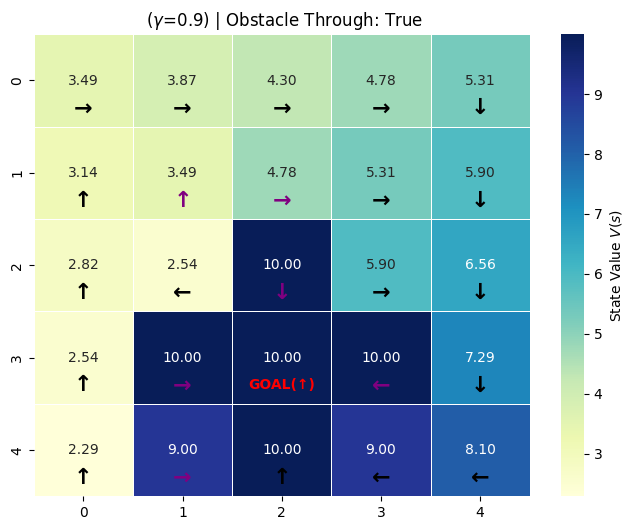

In [86]:
visualize_grid(V_value_iteraction, policy, OBSTACLE, obstacle_through=obstacle_through)

In [87]:
V_policy_iteraction, _ = policy_iterative_solution(V,THETA,GRID_SIZE, OBSTACLE, ACTION, GAMMA, obstacle_through)

✅ 策略迭代在第 8 次大循环后收敛。


In [88]:
V_policy_iteraction

array([[3.48670938, 3.87412987, 4.30459708, 4.78289398, 5.31433498],
       [3.13803094, 3.48670938, 4.78289398, 5.31433498, 5.90482498],
       [2.82422035, 2.54179081, 9.99992498, 5.90482498, 6.56092498],
       [2.54179081, 9.99992498, 9.99992498, 9.99992498, 7.28992498],
       [2.28760423, 8.99992498, 9.99992498, 8.99992498, 8.09992498]])

In [89]:
policy_iteraction = extract_policy(GRID_SIZE, OBSTACLE, ACTION, GAMMA, V_policy_iteraction, obstacle_through=obstacle_through)
policy_iteraction

array([[1, 1, 1, 1, 2],
       [0, 0, 1, 1, 2],
       [0, 3, 2, 1, 2],
       [0, 1, 0, 3, 2],
       [0, 1, 0, 3, 3]])

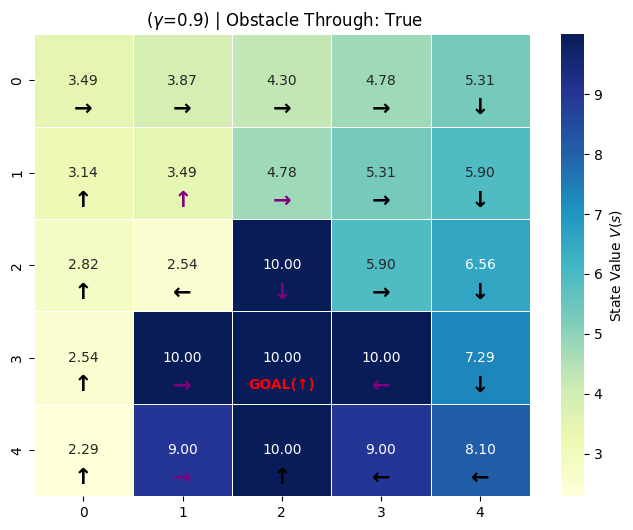

In [90]:
visualize_grid(V_policy_iteraction, policy_iteraction, OBSTACLE, obstacle_through=obstacle_through)